# CatBoost e LightGBM

Este notebook treina uma primeira versão de modelos globais para previsão diária de `faturamento_bruto_dia`.

Modelos avaliados:

- baseline com `lag_7d`;
- baseline com média móvel de 28 dias;
- CatBoost global;
- LightGBM global.

Os modelos são treinados em `target_log1p` e as previsões voltam para reais com `expm1`.


In [1]:
from pathlib import Path
import json

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error


def encontrar_raiz_projeto(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    candidatos = [inicio, *inicio.parents]

    for candidato in candidatos:
        if (candidato / "Base_Modelagem").exists():
            return candidato

    raise FileNotFoundError(
        "Nao foi possivel encontrar a raiz do projeto. "
        "Execute primeiro o notebook 01_base_modelagem_diaria."
    )


ROOT = encontrar_raiz_projeto()
BASE_MODELAGEM = ROOT / "Base_Modelagem"

ARQUIVO_BASE_MODELAGEM = BASE_MODELAGEM / "base_modelagem_diaria.parquet"
ARQUIVO_FEATURES_JSON = BASE_MODELAGEM / "features_modelagem.json"
ARQUIVO_PREDICOES = BASE_MODELAGEM / "predicoes_catboost_lightgbm.parquet"
ARQUIVO_METRICAS = BASE_MODELAGEM / "metricas_catboost_lightgbm.parquet"
ARQUIVO_IMPORTANCIAS = BASE_MODELAGEM / "importancias_catboost_lightgbm.parquet"

RANDOM_STATE = 42

PALETA = {
    "azul": "#2563EB",
    "laranja": "#F97316",
    "verde": "#16A34A",
    "cinza": "#4B5563",
    "cinza_claro": "#E5E7EB",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "axes.titlecolor": "#111827",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": False,
})


## Ler Base e Preparar Matrizes

In [2]:
base = pd.read_parquet(ARQUIVO_BASE_MODELAGEM)
metadata_features = json.loads(ARQUIVO_FEATURES_JSON.read_text(encoding="utf-8"))

ALVO = metadata_features["alvo"]
TARGET_TRANSFORMADO = metadata_features["target_transformado"]
FEATURES_CATEGORICAS = metadata_features["features_categoricas"]
FEATURES_NUMERICAS = metadata_features["features_numericas"]
FEATURES_MODELO = metadata_features["features_modelo"]

for coluna in FEATURES_CATEGORICAS:
    base[coluna] = base[coluna].astype(str).fillna("SEM_INFO")

for coluna in FEATURES_NUMERICAS:
    base[coluna] = pd.to_numeric(base[coluna], errors="coerce").astype("float64").fillna(0)

treino = base[base["conjunto"].eq("treino")].copy()
validacao = base[base["conjunto"].eq("validacao")].copy()
teste = base[base["conjunto"].eq("teste")].copy()

X_train = treino[FEATURES_MODELO].copy()
y_train = treino[TARGET_TRANSFORMADO]
X_val = validacao[FEATURES_MODELO].copy()
y_val = validacao[TARGET_TRANSFORMADO]
X_test = teste[FEATURES_MODELO].copy()
y_test = teste[TARGET_TRANSFORMADO]

cat_features_idx = [X_train.columns.get_loc(coluna) for coluna in FEATURES_CATEGORICAS]

resumo = pd.DataFrame({
    "conjunto": ["treino", "validacao", "teste"],
    "linhas": [len(treino), len(validacao), len(teste)],
    "filiais": [treino["codigo_filial"].nunique(), validacao["codigo_filial"].nunique(), teste["codigo_filial"].nunique()],
    "data_min": [treino["data"].min(), validacao["data"].min(), teste["data"].min()],
    "data_max": [treino["data"].max(), validacao["data"].max(), teste["data"].max()],
})

display(resumo)
display(pd.DataFrame({
    "grupo": ["features_categoricas", "features_numericas", "features_total"],
    "qtd": [len(FEATURES_CATEGORICAS), len(FEATURES_NUMERICAS), len(FEATURES_MODELO)],
}))


,conjunto,linhas,filiais,data_min,data_max
0,treino,60882,100,2024-01-01,2025-08-31
1,validacao,6100,100,2025-09-01,2025-10-31
2,teste,6100,100,2025-11-01,2025-12-31


,grupo,qtd
0,features_categoricas,12
1,features_numericas,40
2,features_total,52


## Funções de Métrica

In [3]:
def desfazer_log(pred_log):
    return np.expm1(pred_log).clip(min=0)


def calcular_metricas(y_real, y_pred, modelo, conjunto):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    erro = y_pred - y_real

    denominador_wape = np.abs(y_real).sum()
    denominador_smape = np.abs(y_real) + np.abs(y_pred)
    smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)

    return {
        "modelo": modelo,
        "conjunto": conjunto,
        "linhas": len(y_real),
        "mae": mean_absolute_error(y_real, y_pred),
        "rmse": mean_squared_error(y_real, y_pred, squared=False),
        "wape": np.abs(erro).sum() / denominador_wape if denominador_wape else np.nan,
        "smape": smape.mean(),
        "bias_pct": erro.sum() / y_real.sum() if y_real.sum() else np.nan,
        "faturamento_real": y_real.sum(),
        "faturamento_previsto": y_pred.sum(),
    }


def avaliar_predicoes(df_base, pred_col, modelo):
    return [
        calcular_metricas(df_base[ALVO], df_base[pred_col], modelo, conjunto)
        for conjunto, df_base in df_base.groupby("conjunto")
    ]


def metricas_por_filial(df_base, pred_col, modelo):
    linhas = []
    for (conjunto, filial), grupo in df_base.groupby(["conjunto", "codigo_filial"]):
        linhas.append(calcular_metricas(grupo[ALVO], grupo[pred_col], modelo, conjunto) | {"codigo_filial": filial})
    return pd.DataFrame(linhas)


## Baselines

In [4]:
predicoes = base[["codigo_filial", "data", "conjunto", ALVO]].copy()
predicoes["baseline_lag_7d"] = base["faturamento_bruto_lag_7d"].clip(lower=0)
predicoes["baseline_media_movel_28d"] = base["faturamento_bruto_media_movel_28d"].clip(lower=0)

metricas = []
for modelo in ["baseline_lag_7d", "baseline_media_movel_28d"]:
    metricas.extend(avaliar_predicoes(predicoes[predicoes["conjunto"].isin(["validacao", "teste"])], modelo, modelo))

display(pd.DataFrame(metricas))


C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and wi

,modelo,conjunto,linhas,mae,rmse,wape,smape,bias_pct,faturamento_real,faturamento_previsto
0,baseline_lag_7d,teste,6100,28556.911954,54722.907219,0.315415,0.293440,0.025392,5.522794e+08,5.663031e+08
1,baseline_lag_7d,validacao,6100,18999.878675,29540.708454,0.225809,0.223871,-0.006563,5.132620e+08,5.098935e+08
2,baseline_media_movel_28d,teste,6100,25110.558994,43861.929999,0.277349,0.291185,0.005160,5.522794e+08,5.551293e+08
3,baseline_media_movel_28d,validacao,6100,18472.012825,27795.049872,0.219536,0.239296,-0.002821,5.132620e+08,5.118143e+08


## CatBoost

In [5]:
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=800,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=6,
    random_seed=RANDOM_STATE,
    early_stopping_rounds=80,
    verbose=False,
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

predicoes.loc[predicoes["conjunto"].eq("validacao"), "catboost"] = desfazer_log(catboost_model.predict(X_val))
predicoes.loc[predicoes["conjunto"].eq("teste"), "catboost"] = desfazer_log(catboost_model.predict(X_test))

metricas.extend(avaliar_predicoes(predicoes[predicoes["conjunto"].isin(["validacao", "teste"])], "catboost", "catboost"))

print("Best iteration CatBoost:", catboost_model.get_best_iteration())
display(pd.DataFrame(metricas).query("modelo == 'catboost'"))


Best iteration CatBoost: 114


C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and wi

,modelo,conjunto,linhas,mae,rmse,wape,smape,bias_pct,faturamento_real,faturamento_previsto
4,catboost,teste,6100,18630.165676,39396.854238,0.205773,0.221857,-0.08913,5.522794e+08,5.030547e+08
5,catboost,validacao,6100,14219.538147,23179.098473,0.168996,0.187369,-0.02899,5.132620e+08,4.983827e+08


## LightGBM

In [6]:
def preparar_lightgbm(X):
    X_lgb = X.copy()
    for coluna in FEATURES_CATEGORICAS:
        X_lgb[coluna] = X_lgb[coluna].astype("category")
    return X_lgb


X_train_lgb = preparar_lightgbm(X_train)
X_val_lgb = preparar_lightgbm(X_val)
X_test_lgb = preparar_lightgbm(X_test)

lightgbm_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lightgbm_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_val_lgb, y_val)],
    eval_metric="rmse",
    categorical_feature=FEATURES_CATEGORICAS,
    callbacks=[lgb.early_stopping(80, verbose=False)],
)

predicoes.loc[predicoes["conjunto"].eq("validacao"), "lightgbm"] = desfazer_log(lightgbm_model.predict(X_val_lgb))
predicoes.loc[predicoes["conjunto"].eq("teste"), "lightgbm"] = desfazer_log(lightgbm_model.predict(X_test_lgb))

metricas.extend(avaliar_predicoes(predicoes[predicoes["conjunto"].isin(["validacao", "teste"])], "lightgbm", "lightgbm"))

print("Best iteration LightGBM:", lightgbm_model.best_iteration_)
display(pd.DataFrame(metricas).query("modelo == 'lightgbm'"))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005950 seconds.
You can set `force_col_wise=true` to remove the overhead.


[LightGBM] [Info] Total Bins 5421
[LightGBM] [Info] Number of data points in the train set: 60882, number of used features: 51
[LightGBM] [Info] Start training from score 10.939113


Best iteration LightGBM: 442


C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and wi

,modelo,conjunto,linhas,mae,rmse,wape,smape,bias_pct,faturamento_real,faturamento_previsto
6,lightgbm,teste,6100,17703.654551,35853.365762,0.195539,0.217310,-0.087312,5.522794e+08,5.040585e+08
7,lightgbm,validacao,6100,13368.932454,21137.571182,0.158887,0.175803,-0.026700,5.132620e+08,4.995580e+08


## Comparar Resultados

,modelo,conjunto,linhas,mae,rmse,wape,smape,bias_pct,faturamento_real,faturamento_previsto
0,lightgbm,teste,6100,17703.654551,35853.365762,0.195539,0.217310,-0.087312,5.522794e+08,5.040585e+08
1,catboost,teste,6100,18630.165676,39396.854238,0.205773,0.221857,-0.089130,5.522794e+08,5.030547e+08
2,baseline_media_movel_28d,teste,6100,25110.558994,43861.929999,0.277349,0.291185,0.005160,5.522794e+08,5.551293e+08
3,baseline_lag_7d,teste,6100,28556.911954,54722.907219,0.315415,0.293440,0.025392,5.522794e+08,5.663031e+08
4,lightgbm,validacao,6100,13368.932454,21137.571182,0.158887,0.175803,-0.026700,5.132620e+08,4.995580e+08
5,catboost,validacao,6100,14219.538147,23179.098473,0.168996,0.187369,-0.028990,5.132620e+08,4.983827e+08
6,baseline_media_movel_28d,validacao,6100,18472.012825,27795.049872,0.219536,0.239296,-0.002821,5.132620e+08,5.118143e+08
7,baseline_lag_7d,validacao,6100,18999.878675,29540.708454,0.225809,0.223871,-0.006563,5.132620e+08,5.098935e+08


C:\Users\celso\AppData\Local\Temp\ipykernel_23384\2806360840.py:12: RuntimeWarning: invalid value encountered in divide
  smape = np.where(denominador_smape > 0, 2 * np.abs(erro) / denominador_smape, 0)
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5

C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mea

,modelo,conjunto,linhas,mae,rmse,wape,smape,bias_pct,faturamento_real,faturamento_previsto,codigo_filial
48,baseline_lag_7d,teste,61,26401.030984,36902.398427,0.204939,0.214580,0.017371,7858236.22,7994743.29,1656
18,baseline_lag_7d,teste,61,42826.710164,64092.239326,0.214041,0.196513,0.020601,12205259.86,12456696.50,1557
54,baseline_lag_7d,teste,61,15631.821311,23015.988234,0.214986,0.216951,0.019650,4435362.99,4522516.03,1674
73,baseline_lag_7d,teste,61,23159.399180,29269.780990,0.219116,0.222647,0.013900,6447377.77,6536998.52,1737
41,baseline_lag_7d,teste,61,16451.296557,23209.783901,0.222368,0.233289,0.020347,4512930.31,4604756.52,1635
21,baseline_lag_7d,teste,61,23464.355082,28612.790761,0.224457,0.221981,0.021361,6376824.66,6513039.18,1566
9,baseline_lag_7d,teste,61,20814.904754,30082.292496,0.226006,0.216005,0.032068,5618022.36,5798179.09,1527
2,baseline_lag_7d,teste,61,23918.577049,32200.061200,0.232948,0.235282,0.041674,6263343.01,6524364.07,1506
36,baseline_lag_7d,teste,61,37403.653443,53053.194303,0.234683,0.224340,0.027899,9722140.20,9993380.12,1614
11,baseline_lag_7d,teste,61,18152.030492,24055.871731,0.240011,0.247493,0.038617,4613435.64,4791592.08,1536


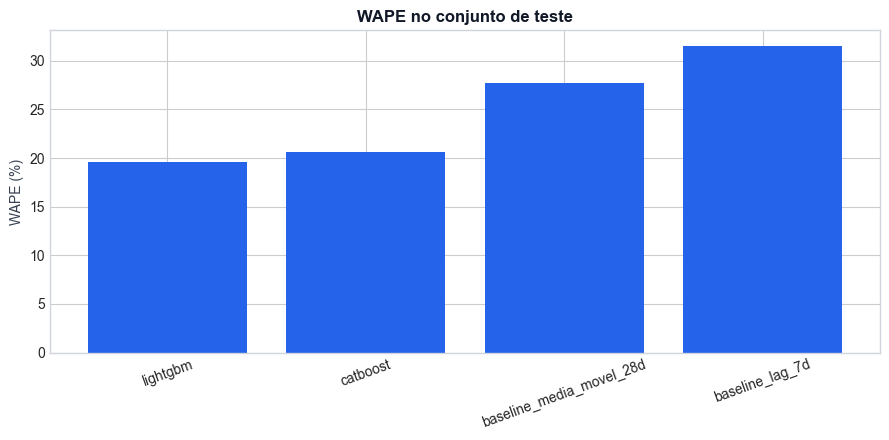

In [7]:
metricas_modelos = pd.DataFrame(metricas).sort_values(["conjunto", "wape", "mae"]).reset_index(drop=True)
display(metricas_modelos)

metricas_filial = []
for modelo in ["baseline_lag_7d", "baseline_media_movel_28d", "catboost", "lightgbm"]:
    metricas_filial.append(metricas_por_filial(predicoes[predicoes["conjunto"].isin(["validacao", "teste"])].dropna(subset=[modelo]), modelo, modelo))
metricas_filial = pd.concat(metricas_filial, ignore_index=True)

display(metricas_filial.sort_values(["conjunto", "modelo", "wape"]).head(20))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_metricas = metricas_modelos[metricas_modelos["conjunto"].eq("teste")].sort_values("wape")
ax.bar(plot_metricas["modelo"], plot_metricas["wape"] * 100, color=PALETA["azul"])
ax.set_title("WAPE no conjunto de teste")
ax.set_ylabel("WAPE (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Importância de Features

In [8]:
importancias = []

for feature, valor in zip(FEATURES_MODELO, catboost_model.get_feature_importance()):
    importancias.append({"modelo": "catboost", "feature": feature, "importancia": valor})

for feature, valor in zip(FEATURES_MODELO, lightgbm_model.feature_importances_):
    importancias.append({"modelo": "lightgbm", "feature": feature, "importancia": valor})

importancias = pd.DataFrame(importancias)

display(
    importancias.sort_values(["modelo", "importancia"], ascending=[True, False])
    .groupby("modelo")
    .head(20)
)


,modelo,feature,importancia
40,catboost,quantidade_lag_7d,17.676841
43,catboost,share_med_faturamento_lag_7d,14.664653
39,catboost,cupons_lag_7d,13.581440
41,catboost,faturamento_med_lag_7d,8.924960
17,catboost,dia_semana_id,6.950776
22,catboost,eh_feriado_bancario,5.060550
31,catboost,periodo_ordem,4.718530
36,catboost,faturamento_bruto_lag_7d,4.525528
32,catboost,dias_desde_primeira_venda,3.415267
42,catboost,faturamento_n_med_lag_7d,2.593376


## Salvar Saídas

In [9]:
predicoes.to_parquet(ARQUIVO_PREDICOES, index=False)
metricas_modelos.to_parquet(ARQUIVO_METRICAS, index=False)
importancias.to_parquet(ARQUIVO_IMPORTANCIAS, index=False)

display(pd.Series({
    "predicoes": str(ARQUIVO_PREDICOES),
    "metricas": str(ARQUIVO_METRICAS),
    "importancias": str(ARQUIVO_IMPORTANCIAS),
}).to_frame("arquivo"))


,arquivo
predicoes,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\pred...
metricas,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\metr...
importancias,E:\trabalhos\PROJ3- Panvel\Base_Modelagem\impo...
